In [1]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
import copy
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import os
import matplotlib.pyplot as plt

In [2]:

EXTRA_COLS = ['clim_precip', 'clim_temp', 'soil_texture', 'topo_elevation', 'topo_slope']
IN_CHANNELS = 14 + len(EXTRA_COLS)  
MODEL_NAME  = 'model_arkansas_cnn_gru'

In [3]:
class CNNFeatureExtractor_V2(nn.Module):
    def __init__(self, in_channels=19):
        super(CNNFeatureExtractor_V2, self).__init__()
        # On utilise des dilatations pour voir plus large sans perdre de résolution
        self.conv1 = nn.Conv1d(in_channels, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(128)
        self.conv2 = nn.Conv1d(128, 128, kernel_size=3, padding=2, dilation=2) # Vision dilatée
        self.bn2 = nn.BatchNorm1d(128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x: [B, T, C] -> [B, 19, 36]
        x = x.transpose(1, 2)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.conv2(x)))
        # Sortie : [B, 128, 36]
        return x.transpose(1, 2)

class BiGRUProcessor_V2(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=128):
        super(BiGRUProcessor_V2, self).__init__()
        # Une seule couche robuste
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        # Sortie : 128 * 2 = 256
        
    def forward(self, x):
        out, _ = self.gru(x)
        return out



class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim=256): # On passe à 256
        super(TemporalAttention, self).__init__()
        # Cette couche va apprendre à donner un score à chaque date
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: [B, 36, 256]
        
        # 1. Calcul de l'énergie (importance brute de chaque date)
        energy = self.attn(x) # Result: [B, 36, 1]
        
        # 2. Normalisation Softmax : les poids de toutes les dates somment à 1
        # Cela crée une "probabilité" d'importance
        weights = torch.softmax(energy, dim=1) # [B, 36, 1]
        
        # 3. Application des poids sur les features originales
        # On multiplie chaque date par son importance et on fait la somme
        context = torch.sum(weights * x, dim=1) # Result: [B, 256]
        
        return context, weights



class HybridCropNet_V2(nn.Module):
    def __init__(self, num_classes=6, in_channels=19):
        super(HybridCropNet_V2, self).__init__()
        self.feature_extractor = CNNFeatureExtractor_V2(in_channels=in_channels)
        self.sequence_processor = BiGRUProcessor_V2(input_dim=128, hidden_dim=128)
        self.attention = TemporalAttention(hidden_dim=256) # Attention sur 256
        
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)  # [B, 36, 128]
        x = self.sequence_processor(x) # [B, 36, 256]
        context, weights = self.attention(x)
        logits = self.classifier(context)
        return logits, weights

In [4]:
df_ark = pd.read_csv('../data/arkansas_preprocessed_v2.csv')
df_ark.head()

,d0_B2,d0_B3,d0_B4,d0_B5,d0_B6,d0_B7,d0_B8,d0_B8A,d0_B11,d0_B12,...,d35_B8A,d35_B11,d35_B12,clim_precip,clim_temp,soil_texture,topo_elevation,topo_slope,cropland,target_class
0,0.0505,0.0758,0.10135,0.12890,0.1361,0.14435,0.16065,0.15805,0.11945,0.07645,...,0.19435,0.1425,0.09335,-1.852316,-2.559609,0.545543,0.527846,-0.696317,3,2
1,0.0645,0.0857,0.11530,0.13840,0.1542,0.16320,0.18710,0.18750,0.25540,0.19040,...,0.24080,0.2744,0.18450,-0.435476,-0.189180,0.545543,0.067849,-0.696317,2,1
2,0.0867,0.1072,0.14110,0.15910,0.1697,0.18090,0.20630,0.20340,0.22120,0.15450,...,0.20600,0.2376,0.17190,-0.874820,-0.424767,0.545543,0.251848,-1.295287,1,0
3,0.0631,0.0884,0.11200,0.14830,0.1979,0.21770,0.24190,0.23800,0.24200,0.17210,...,0.24190,0.3148,0.24250,0.735092,1.232434,0.545543,-1.036141,0.500368,2,1
4,0.0590,0.0772,0.09770,0.11405,0.1153,0.12705,0.13900,0.13425,0.13860,0.08885,...,0.09675,0.1053,0.06840,-0.436471,-0.184275,-1.790829,0.113849,-1.295287,1,0


In [5]:
mapping_ark = {1: 0, 2: 1, 3: 2, 5: 3}
def map_classes_ark(val):
    return mapping_ark.get(val, 4)

df_ark['target_class'] = df_ark['cropland'].apply(map_classes_ark)

targets_ark = {0: 4677, 1: 762, 2: 2423, 3: 1522, 4: 616}
sampled_dfs = []
for class_id, count in targets_ark.items():
    sub_df = df_ark[df_ark['target_class'] == class_id]
    sampled_dfs.append(sub_df.sample(n=min(len(sub_df), count), random_state=42))

df_ark_final = pd.concat(sampled_dfs).sample(frac=1, random_state=42)
print(df_ark_final['target_class'].value_counts())

target_class
0    4677
2    2423
3    1522
1     762
4     616
Name: count, dtype: int64


In [6]:
print(df_ark['target_class'].value_counts())
print(f"Total : {len(df_ark)}")

target_class
0    4677
2    2423
3    1522
1     762
4     616
Name: count, dtype: int64
Total : 10000


In [7]:
def prepare_mixed_hybrid_data(df, extra_cols):
    """
    Prépare les données en mode 'Mixte' (14 spectrales + 5 environnementales).
    Total features par date : 19
    Format de sortie : [Batch, 36, 19]
    """
    BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    
    # 1. Calcul des indices (Ton bloc actuel)
    for i in range(36):
        b3, b4, b5, b8 = df[f'd{i}_B3'], df[f'd{i}_B4'], df[f'd{i}_B5'], df[f'd{i}_B8']
        df[f'd{i}_NDVI']  = (b8 - b4) / (b8 + b4 + 1e-8)
        df[f'd{i}_NDRE']  = (b8 - b5) / (b8 + b5 + 1e-8)
        df[f'd{i}_LCI']   = (b8 - b5) / (b8 + b4 + 1e-8)
        df[f'd{i}_GNDVI'] = (b8 - b3) / (b8 + b3 + 1e-8)

    # 2. Extraction des 14 features spectrales
    PURE_FEATURES = BANDS + ['NDVI', 'NDRE', 'LCI', 'GNDVI']
    ordered_cols = [f'd{i}_{feat}' for i in range(36) for feat in PURE_FEATURES]
    x_spectral = torch.tensor(df[ordered_cols].values, dtype=torch.float32).view(-1, 36, 14)
    
    # 3. Intégration des 5 EXTRA_COLS (Mode Contextuel)
    if extra_cols and len(extra_cols) > 0:
        # On prend les colonnes statiques (ex: elevation, soil_texture)
        x_extra = torch.tensor(df[extra_cols].values, dtype=torch.float32)
        # On les "étire" sur les 36 dates : [Batch, 5] -> [Batch, 36, 5]
        x_extra_expanded = x_extra.unsqueeze(1).expand(-1, 36, -1)
        # Fusion : [Batch, 36, 14 + 5] = [Batch, 36, 19]
        x_final = torch.cat([x_spectral, x_extra_expanded], dim=-1)
    else:
        x_final = x_spectral
    
    y = torch.tensor(df['target_class'].values, dtype=torch.long)
    return x_final, y

# --- Utilisation ---
EXTRA_COLS = ['clim_precip', 'clim_temp', 'soil_texture', 'topo_elevation', 'topo_slope']
IN_CHANNELS = 14 + len(EXTRA_COLS) # 19

x_ark, y_ark = prepare_mixed_hybrid_data(df_ark_final, EXTRA_COLS)

print(f'Nouveau Shape X: {x_ark.shape}') # Doit être [Batch, 36, 19]

Nouveau Shape X: torch.Size([10000, 36, 19])


C:\Users\lhadi\AppData\Local\Temp\ipykernel_15644\590579815.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'd{i}_NDVI']  = (b8 - b4) / (b8 + b4 + 1e-8)
C:\Users\lhadi\AppData\Local\Temp\ipykernel_15644\590579815.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'd{i}_NDRE']  = (b8 - b5) / (b8 + b5 + 1e-8)
C:\Users\lhadi\AppData\Local\Temp\ipykernel_15644\590579815.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performanc

In [8]:
# Split simplifié (sans les masques)
x_train, x_temp, y_train, y_temp = train_test_split(
    x_ark, y_ark, test_size=0.18, stratify=y_ark, random_state=64
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.8, stratify=y_temp, random_state=64
)

# Loaders propres
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val, y_val),   batch_size=256)
test_loader  = DataLoader(TensorDataset(x_test, y_test),  batch_size=256)

In [9]:
import copy
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import torch
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F

# --- 1. Focal Loss pour cibler les Almonds/Pistachios ---
class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=1, gamma=1.5, weight=None): # Gamma 1.5 pour l'équilibre Precision/Recall
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight, label_smoothing=0.1)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 50 
best_f1 = 0.0
print(f'Device utilisé : {device}')

# --- 2. Initialisation du modèle ---
# Assure-toi que IN_CHANNELS est bien défini (19 si tu as inclus sol/topo)
model = HybridCropNet_V2(num_classes=6, in_channels=IN_CHANNELS).to(device)

# --- 3. Optimizer & Criterion ---
# AdamW est souvent meilleur pour les architectures avec attention
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Poids stratégiques (Sweet Spot trouvé précédemment)
weights = torch.tensor([1.1, 1.0, 1.1, 1.8, 1.8, 0.8]).to(device)
criterion = FocalLoss(weight=weights)

# Scheduler pour affiner la convergence
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f'Époque {epoch+1}/{epochs}', unit='batch')
    
    for b_x, b_y in pbar:
        b_x, b_y = b_x.to(device), b_y.to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(b_x) 
        loss = criterion(outputs, b_y)
        loss.backward()
        
        # Stability check
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}', lr=f'{optimizer.param_groups[0]["lr"]:.6f}')

    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0
    with torch.no_grad():
        for b_x, b_y in val_loader:
            b_x, b_y = b_x.to(device), b_y.to(device)
            outputs, _ = model(b_x)
            val_loss += criterion(outputs, b_y).item()
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_targets.extend(b_y.cpu().numpy())

    # Calcul des métriques
    precision, recall, f1, _ = precision_recall_fscore_support(
        val_targets, val_preds, average='macro', zero_division=0
    )
    val_acc = 100 * np.sum(np.array(val_preds) == np.array(val_targets)) / len(val_targets)
    
    # Update scheduler
    scheduler.step(f1)
    
    print(f'\n[Validation] Acc: {val_acc:.2f}% | F1-Score: {f1:.4f}')

    if f1 > best_f1:
        best_f1 = f1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f'Nouveau record F1: {best_f1:.4f}')

# Rechargement du meilleur état
model.load_state_dict(best_model_state)
print(f'\nEntraînement fini. Meilleur F1 atteint: {best_f1:.4f}')

Device utilisé : cuda


Époque 1/50: 100%|██████████| 33/33 [00:02<00:00, 12.01batch/s, loss=0.7798, lr=0.001000]



[Validation] Acc: 55.28% | F1-Score: 0.4368
Nouveau record F1: 0.4368


Époque 2/50: 100%|██████████| 33/33 [00:00<00:00, 73.66batch/s, loss=0.9484, lr=0.001000]



[Validation] Acc: 59.17% | F1-Score: 0.4604
Nouveau record F1: 0.4604


...


[Validation] Acc: 93.33% | F1-Score: 0.9184


Époque 49/50: 100%|██████████| 33/33 [00:00<00:00, 92.89batch/s, loss=0.1982, lr=0.000063]



[Validation] Acc: 93.61% | F1-Score: 0.9266


Époque 50/50: 100%|██████████| 33/33 [00:00<00:00, 90.38batch/s, loss=0.2650, lr=0.000063]



[Validation] Acc: 93.61% | F1-Score: 0.9310

Entraînement fini. Meilleur F1 atteint: 0.9385


In [10]:
torch.save(model.state_dict(), f'models/model_arkansas_CNN_GRU.pth')
print('Modèle sauvegardé : model_arkansas_CNN_GRU.pth')

Modèle sauvegardé : model_arkansas_CNN_GRU.pth


=== Test Set - HybridCropNet ===
OA    : 0.9417
Kappa : 0.9158
              precision    recall  f1-score   support

    Soybeans       0.97      0.95      0.96       673
      Cotton       0.97      0.95      0.96       110
        Rice       0.96      0.94      0.95       349
        Corn       0.84      0.91      0.88       219
      Others       0.90      0.92      0.91        89

    accuracy                           0.94      1440
   macro avg       0.93      0.94      0.93      1440
weighted avg       0.94      0.94      0.94      1440



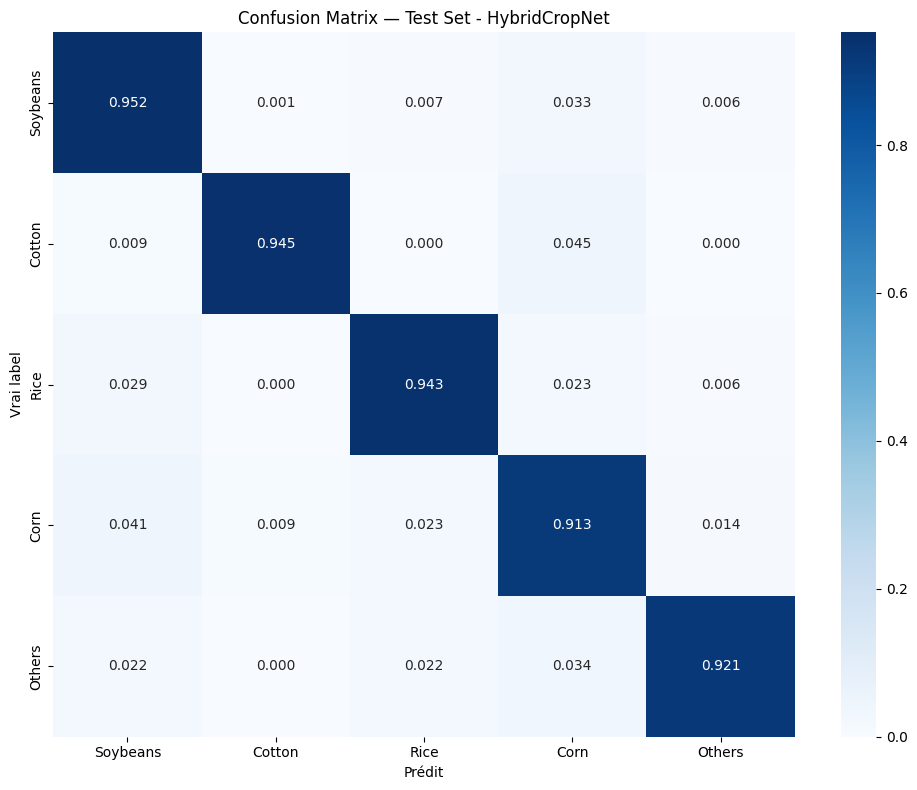

In [11]:
def evaluate_on_test(model, test_loader, class_names, title):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        # 1. On unpack seulement 2 valeurs (X et Y)
        for b_x, b_y in test_loader:
            b_x, b_y = b_x.to(device), b_y.to(device)
            
            # 2. On unpack les 2 sorties du nouveau modèle (logits et weights)
            outputs, _ = model(b_x) 
            
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(b_y.cpu().numpy())
            
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calcul des métriques globales
    oa    = (all_preds == all_labels).mean()
    kappa = cohen_kappa_score(all_labels, all_preds)
    
    print(f'=== {title} ===')
    print(f'OA    : {oa:.4f}')
    print(f'Kappa : {kappa:.4f}')
    
    # Rapport détaillé par classe (c'est là qu'on verra le score des Amandes !)
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.3f', xticklabels=class_names,
                yticklabels=class_names, cmap='Blues')
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédit')
    plt.tight_layout()
    
    # Sauvegarde
    os.makedirs('./figs', exist_ok=True)
    plt.savefig(f'./figs/CNNGRU_confusion_matrix.png', dpi=150)
    plt.show()


class_names = ['Soybeans', 'Cotton', 'Rice', 'Corn', 'Others']
evaluate_on_test(model, test_loader, class_names, title='Test Set - HybridCropNet')